# PyPSA: Modelling Capacity Expansion Scenarios

## Individual learning outcomes

- Interpret the results from a PyPSA model, understanding the difference between model parameters and variables (inputs and results)
- See what insights can be obtained from the model, and how assumptions and data quality affect the results
- Use exploratory and normative scenarios approaches to structure a modelling analysis

<img src="https://docs.pypsa.org/latest/assets/logo/logo-primary-light.svg#only-light" width="300px" />

:::{note}
Also in this tutorial, you might want to refer to the PyPSA documentation for more details: https://docs.pypsa.org.
:::

## Mathematical representation of capacity expansion planning

Review the problem formulation of the power system model. Below you can find an adapted version
where the capacity limits have been promoted to **decision variables** with corresponding terms
in the *objective function* and *new constraints for their expansion limits* (e.g. wind and solar potentials). This is known as **capacity expansion problem**.

\begin{equation*}
    \min_{g,e,f,G,E,F} \quad \sum_{i,s,t} w_t o_{s} g_{i,s,t} + \sum_{i,s} c_sG_{i,s}  + c_{r,\text{dis/charge}}G_{i,r, \text{dis/charge}} +   c_{r}E_{i,r}  + c_\ell F_{\ell}
  \end{equation*}
such that
  \begin{align*}
    d_{i,t} &= \sum_s g_{i,s,t}  - \sum_\ell K_{i\ell} f_{\ell,t}   & \text{energy balance} \\
    0 &\leq g_{i,s,t} \leq \hat{g}_{i,s,t} G_{i,s} & \text{generator limits}\\
    0 & \leq g_{i,r,t,\text{dis/charge}} \leq G_{i,r,\text{dis/charge}}& \text{storage dis/charge limits} \\
    0 & \leq e_{i,r,t} \leq E_{r} & \text{storage energy limits} \\ 
    e_{i,r,t} &= \eta^0_{i,r,t} e_{i,r,t-1} + \eta^1_{r}g_{i,r,t,\text{charge}} -  \frac{1}{\eta^2_{r}} g_{i,r,t,\text{discharge}} & \text{storage consistency} \\
    -F_\ell &\leq f_{\ell,t} \leq F_\ell  & \text{line limits} \\
    0 &= \sum_\ell C_{\ell c} x_\ell f_{\ell,t} & \text{KVL} \\
        \underline{G}_{i,s} & \leq G_{i,s} \leq \overline{G}_{i,s} & \text{generator capacity expansion limits} \\
    \underline{G}_{i,r, \text{dis/charge}} & \leq G_{i,r, \text{dis/charge}} \leq \overline{G}_{i,r, \text{dis/charge}} & \text{storage power capacity expansion limits} \\
    \underline{E}_{i,r} & \leq E_{i,r} \leq \overline{E}_{i,r} & \text{storage energy expansion limits} \\
    \underline{F}_{\ell} & \leq F_{\ell} \leq \overline{F}_{\ell} & \text{line capacity expansion limits}
  \end{align*}

**New decision variables for capacity expansion planning:**

- $G_{i,s}$ is the generator capacity at bus $i$, technology $s$,
- $F_{\ell}$ is the transmission capacity of line $\ell$,
- $G_{i,r,\text{dis-/charge}}$ denotes the charge and discharge capacities of storage unit $r$ at bus $i$,
- $E_{i,r}$ is the energy capacity of storage $r$ at bus $i$ and time step $t$.

**New parameters for capacity expansion planning:**

- $c_{\star}$ is the capital cost of technology $\star$ at bus $i$
- $w_t$ is the weighting of time step $t$ (e.g. number of hours it represents)
- $\underline{G}_\star, \underline{F}_\star, \underline{E}_\star$ are the minimum capacities per technology and location/connection.
- $\underline{G}_\star, \underline{F}_\star, \underline{E}_\star$ are the maximum capacities per technology and location.

:::{note}
For a full reference to the optimisation problem description, see https://docs.pypsa.org/latest/user-guide/optimization/overview/
:::

:::{note}
If you have not yet set up Python on your computer, you can execute this tutorial in your browser via [Google Colab](https://colab.research.google.com/). Download the `.ipynb` file using the download button on the top right corner and import it in [Google Colab](https://colab.research.google.com/).

Then install the following packages by executing the following command in a Jupyter cell at the top of the notebook.

```sh
!pip install pypsa pandas matplotlib plotly"<6"
```
:::

First, we need a few packages for this tutorial:

In [1]:
import pypsa
import pandas as pd

## Technology Data Inputs

A technology database (https://github.com/PyPSA/technology-data) is a part of PyPSA ecosystem which collects assumptions and projections for energy system technologies (such as costs, efficiencies, lifetimes, etc.) for given years, which we can load into a `pandas.DataFrame`. This requires some pre-processing to load (e.g. converting units, setting defaults, re-arranging dimensions).

### Toolset available

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

Let's also import a small utility function that calculates the **annuity** to annualise investment costs. The formula is

$$
a(r, n) = \frac{r}{1-(1+r)^{-n}}
$$
where $r$ is the discount rate and $n$ is the lifetime. If $r=0$, the annuity simplifies to $a(0,n) = \frac{1}{n}$. If $n=\infty$, the annuity simplifies to $a(r, \infty) = r$.

In [3]:
# from pypsa.costs import annuity
def annuity(t: float | pd.Series, r: float | pd.Series) -> float | pd.Series:
    """
    Calculate the annuity factor for an asset with lifetime t years and.

    discount rate of r, e.g. annuity(20, 0.05) * 20 = 1.6

    parameters
    ----------
    t : int or pd.Series
        Lifetime of the asset in years.
    r : float or pd.Series
        Discount rate (e.g. 0.05 for 5%).

    Returns
    -------
    float or pd.Series
        Annuity factor, i.e. the ratio of fixed annualized cost to initial investment.
    """

    if isinstance(r, pd.Series):
        return pd.Series(1 / t, index=r.index).where(
            r == 0, r / (1.0 - 1.0 / (1.0 + r) ** t)
        )
    elif r > 0:
        return r / (1.0 - 1.0 / (1.0 + r) ** t)
    else:
        return 1 / t

In [4]:
annuity(t=40, r=0.07)

0.07500913887361031

### Practical implications

Based on this, we can calculate costs in PyPSA.

The short-term marginal generation costs (STMGC, €/MWh) are named `marginal_cost` and calculated as follows:

In [5]:
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

The annualised investment costs (`capital_cost` in PyPSA terms, €/MW/a) are calculated using annuity

In [6]:
annuity_factor = annuity(costs["discount rate"], costs["lifetime"])

### Emissions data

In [7]:
carrier_names = ["coal", "gas", "oil"]

In [8]:
carriers_emissions_list = [
    costs.at[c, "CO2 intensity"] if c in costs.index else 0 for c in carrier_names
]

In [9]:
carriers_emissions_dict = dict(zip(carrier_names, carriers_emissions_list))

In [10]:
carriers_emissions_dict["coal"]

0.3361

## Loading time series data

We are also going to need some time series for hydro, solar and load. For that, we are using some outputs of a current default dispatch run of PyPSA-Zambia model for year 2023.

In [11]:
ts_year = pd.read_csv("scenarios_inputs.csv", index_col=0)

In [12]:
ts = ts_year[:12]

In [13]:
ts = ts.set_index("time")

Time-varying inputs

In [14]:
ts

,load,load_2030,solar,hydro
time,,,,
2023-01-01 00:00:00,1262.772707,1641.604520,0.000000,247.852300
2023-01-01 03:00:00,1264.437106,1643.768238,0.001475,323.276012
2023-01-01 06:00:00,1339.341534,1741.143994,0.116654,246.626506
2023-01-01 09:00:00,1437.178810,1868.332453,0.323262,257.865338
2023-01-01 12:00:00,1428.652936,1857.248817,0.331891,434.256283
2023-01-01 15:00:00,1469.822059,1910.768677,0.102593,759.109358
2023-01-01 18:00:00,1545.857873,2009.615235,0.000000,817.673933
2023-01-01 21:00:00,1371.515577,1782.970251,0.000000,508.473758
2023-01-02 00:00:00,1251.017393,1626.322611,0.000000,520.137318


## Model Initialisation

**In this section, we will build a one-node model which calculates the cost of meeting a national electricity demand.** This simplified representation follows the ideas sketched in [model.energy](https://model.energy) which explores opportunities to cover the electricity demand from renewable sources for different regions of the world.

We improve from [model.energy](https://model.energy) by including an electricity demand profile rather than a constant electricity demand, and accounting for the existing generation and possible delays in generation deployment.

For building the model, we start again by initialising an empty network.

In [15]:
n = pypsa.Network()

Then, we add all the technologies we are going to include as carriers.

In [16]:
n.add(
    "Carrier",
    "coal",
    color="grey",
    nice_name="Coal",
    co2_emissions=carriers_emissions_dict["coal"],
)

In [17]:
carriers = [
    "hydro",    
    "solar",
    "biomass",
    "electricity",
]
colors=[
    "dodgerblue",
    "gold",
    "forestgreen",
    "indianred",
]
nice_names=[
    "Hydro",
    "Solar",
    "Biomass",
    "AC"
]

for i, c in enumerate(carriers):
    n.add(
        "Carrier",
        c,
        color=colors[i],
        nice_name=nice_names[i],
    )

Then, we add a single bus...

In [18]:
n.add("Bus", "electricity", carrier="electricity")

...and tell the `pypsa.Network` object `n` that the [snapshots](https://docs.pypsa.org/latest/user-guide/design/#snapshots) of the model will be taken from the time series index `ts.index`.

In [19]:
n.snapshots = ts.index

n.snapshots[:12]

Index(['2023-01-01 00:00:00', '2023-01-01 03:00:00', '2023-01-01 06:00:00',
       '2023-01-01 09:00:00', '2023-01-01 12:00:00', '2023-01-01 15:00:00',
       '2023-01-01 18:00:00', '2023-01-01 21:00:00', '2023-01-02 00:00:00',
       '2023-01-02 03:00:00', '2023-01-02 06:00:00', '2023-01-02 09:00:00'],
      dtype='object', name='snapshot')

## Adding Components

We are going to add one dispatchable generation technology to the model. This is a coal power generator:

In [20]:
n.add(
    "Generator",
    "coal",
    bus="electricity",
    carrier="coal",
    p_nom=1250,
    capital_cost=900,
    marginal_cost=250,
    efficiency=0.95,
    p_nom_extendable=False,
)

Next, we add the demand time series to the model.

In [21]:
n.add(
    "Load",
    "demand",
    bus="electricity",
    p_set=ts.load,
)

Let's have a check whether the data was read-in correctly.

<Axes: xlabel='snapshot'>

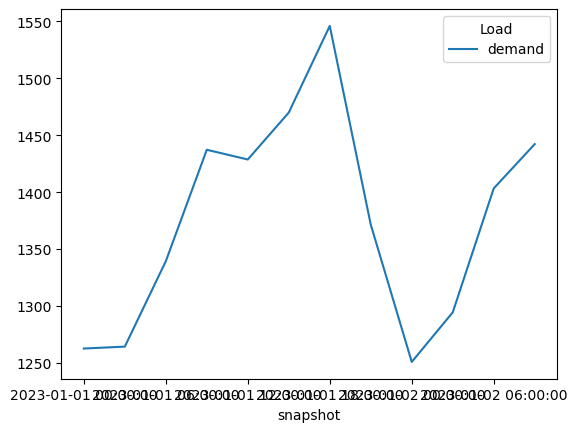

In [22]:
# n.loads_t.p_set.plot(labels=dict(value="Load (MW)"))
n.loads_t.p_set.plot()

#### Initial optimisation run

In [23]:
n.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.01s
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: Infeasible



Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-o2ofmofz has 36 rows; 12 cols; 36 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [2e+02, 2e+02]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+03]
Presolving model
Problem status detected on presolve: Infeasible
Model name          : linopy-problem-o2ofmofz
Model status        : Infeasible
Objective value     :  0.0000000000e+00
HiGHS run time      :          0.00
Writing the solution to /private/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/linopy-solve-o52cz0y7.sol


('warning', 'infeasible')

The model is infeasible which means that a solution can't be found. The reason is lack of generation capacity which would be sufficient to cover the demand. To fix that, we will add load shedding into the model.

#### Load shedding trick

In [24]:
n.add(
    "Carrier",
    "load shedding",
    color="red",
    nice_name="Load Shedding"
)

A fake generator is added to the model to represent load shedding. The load shedding "generator" can be expanded with zero capital cost but has very low marginal cost to make sure the model will use it only if there is no other options to cover demand:

In [25]:
n.add(
    "Generator",
    "load shedding",
    bus="electricity",
    carrier="load shedding",
    p_nom=0,
    capital_cost=0,
    marginal_cost=100_000,
    p_nom_extendable=True,
)

In [26]:
n.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 25 primals, 61 duals
Objective: 1.55e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-gu7he7nk has 61 rows; 25 cols; 85 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [2e+02, 1e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+03]
Presolving model
0 rows, 0 cols, 0 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve : Reductions: rows 0(-61); columns 0(-25); elements 0(-85) - Reduced to empty
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-gu7he7nk
Model status        : Optimal
Objective value     :  1.5480393270e+08
P-D objective error :  1.0588411402e-15
HiGHS run time      :          0.00
Writing the solution to /private/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/linopy-solve-_0ebfz3p.sol


('ok', 'optimal')

Now, the model is optimised. Let's check how the demand is supplied by using `energy_balance` method:

In [27]:
n.statistics.energy_balance()

component  carrier        bus_carrier
Generator  Coal           AC             15000.00000
           Load Shedding  AC              1510.53933
Load       -              AC            -16510.53933
dtype: float64

To avoid load shedding, we need to add more generation capacity to the network. Let's add hydro generation.

We use `StorageUnit` component to represent reservoir hydro generation

In [28]:
n.add(
    "StorageUnit",
    "hydro",
    bus="electricity",
    carrier="hydro",
    max_hours = 240,
    p_max_pu=1.0,  # dispatch
    p_min_pu=0.0,  # store
    inflow=ts["hydro"],
    #capital_cost=200,
    #marginal_cost=0,
    p_nom=750,
    efficiency_dispatch=0.9,
    efficiency_store=0.0,
    cyclic_state_of_charge=True
)

In [29]:
n.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 73 primals, 145 duals
Objective: 2.85e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-a2ngodbi has 145 rows; 73 cols; 229 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [2e+02, 1e+05]
  Bound  [2e+02, 8e+02]
  RHS    [2e+02, 2e+05]
Presolving model
24 rows, 60 cols, 84 nonzeros  0s
Dependent equations search running on 24 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
24 rows, 60 cols, 84 nonzeros  0s
Presolve : Reductions: rows 24(-121); columns 60(-13); elements 84(-145)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 24(22179.4) 0s
         31     2.8521402682e+06 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-a2ngodbi
Model status        : Optimal
Simplex   iterations: 31
Objective value     :  2.8521402

('ok', 'optimal')

In [30]:
n.statistics()

,,Optimal Capacity,Installed Capacity,Supply,Withdrawal,Energy Balance,Transmission,Capacity Factor,Curtailment,Capital Expenditure,Operational Expenditure,Revenue,Market Value
Generator,Coal,1250.0,1250.0,11408.56107,0.00000,11408.56107,0.0,0.760571,3591.43893,1125000.0,2.852140e+06,2.852140e+06,250.000001
Load,-,0.0,0.0,0.00000,16510.53933,-16510.53933,0.0,NaN,0.00000,0.0,0.000000e+00,-4.127635e+06,NaN
StorageUnit,Hydro,750.0,750.0,5101.97825,0.00000,5101.97825,0.0,0.566886,3898.02175,0.0,0.000000e+00,1.275495e+06,250.000003


To add a solar generator, we also need to supply the capacity factor to the model via the attribute `p_max_pu`:

In [31]:
n.add(
    "Generator",
    "solar",
    bus="electricity",
    carrier="solar",
    p_max_pu=ts["solar"],
    capital_cost=0,
    marginal_cost=0.001,
    efficiency=0.95,
    p_nom_extendable=True,
)

In [32]:
n.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 86 primals, 170 duals
Objective: 6.08e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-stp3koh8 has 170 rows; 86 cols; 274 nonzeros
Coefficient ranges:
  Matrix [8e-04, 1e+00]
  Cost   [1e-03, 1e+05]
  Bound  [2e+02, 8e+02]
  RHS    [2e+02, 2e+05]
Presolving model
24 rows, 68 cols, 92 nonzeros  0s
Dependent equations search running on 16 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
16 rows, 44 cols, 60 nonzeros  0s
Presolve : Reductions: rows 16(-154); columns 44(-42); elements 60(-214)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s
         22     6.0779986506e+05 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-stp3koh8
Model status        : Optimal
Simplex   iterations: 22
Objective value     :  6.0779986506e+0

('ok', 'optimal')

In [33]:
n.statistics()

Optimal Capacity  Installed Capacity      Supply  \
Generator   Coal       1.250000e+03              1250.0  2431.16355   
            Solar      1.057885e+06                 0.0  8977.39752   
Load        -          0.000000e+00                 0.0     0.00000   
StorageUnit Hydro      7.500000e+02               750.0  5101.97825   

                    Withdrawal  Energy Balance Transmission  Capacity Factor  \
Generator   Coal       0.00000      2431.16355          0.0         0.162078   
            Solar      0.00000      8977.39752          0.0         0.000707   
Load        -      16510.53933    -16510.53933          0.0              NaN   
StorageUnit Hydro      0.00000      5101.97825          0.0         0.566886   

                    Curtailment  Capital Expenditure  Operational Expenditure  \
Generator   Coal   1.256884e+04            1125000.0             607790.88767   
            Solar  1.168867e+06                  0.0                  8.97740   
Load        -      0.000000e+00                  0.0                  0.00000   
StorageUnit Hydro  3.898022e+03                  0.0                  0.00000   

                        Revenue  Market Value  
Generator   Coal   6.077909e+05    250.000003  
            Solar  8.977400e+00      0.001000  
Load        -     -1.357802e+06           NaN  
StorageUnit Hydro  7.500021e+05    147.002216

### Sensitivity analysis

Sensitivity analyses constitute a core activity of energy system modelling. Below, you can find sensitivity analyses that varies the capital costs of solar:

In [34]:
sensitivity = {}
energy_balance = {}
for solar_costs in [200, 100, 50, 10, 5]:
    n.generators.loc["solar", "capital_cost"] = solar_costs
    n.optimize(solver_name="highs", log_to_console=False)
    sensitivity[solar_costs] = (
        pd.concat([n.statistics.capex(), n.statistics.opex()])
        .groupby("carrier")
        .sum()
        .div(1e9)
    )
    energy_balance[solar_costs] = (
        n.statistics.energy_balance()
        .drop(index="Load", level="component")
        .groupby("carrier")
        .sum()
    )

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 86 primals, 170 duals
Objective: 2.51e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 86 primals, 170 duals
Objective: 2.01e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms


INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 86 primals, 170 duals
Objective: 1.52e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 86 primals, 170 duals
Objective: 9.99e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 86 primals, 170 duals
Objective: 9.32e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms


In [35]:
energy_mix_df = pd.DataFrame(energy_balance).T
energy_mix_df.index.name = "solar capital cost"

In [36]:
energy_mix_df

carrier,Coal,Hydro,Solar
solar capital cost,,,
200,6615.85858,5101.97825,4792.70249
100,4659.71514,5101.97825,6748.84594
50,3793.37116,5101.97825,7615.18991
10,3460.08374,5101.97825,7948.47734
5,3460.08374,5101.97825,7948.47734


In [37]:
df = pd.DataFrame(sensitivity).T
df.index.name = "solar capital cost"

In [38]:
df

carrier,Coal,Solar
solar capital cost,,
200,0.002779,0.000861
100,0.002290,0.000847
50,0.002073,0.000574
10,0.001990,0.000134
5,0.001990,0.000067
